In [4]:
from model_ranking import (
    load_h5,
    adaRandError_eval,
    get_random_colors,
    get_roi_slice,
    per_object_adaRandError_eval,
)
import matplotlib.pyplot as plt
import numpy as np

In [15]:
ov_gt_path = "/scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2.h5"
ov_gt = load_h5(ov_gt_path, "label_with_ignore")
ov_raw = load_h5(ov_gt_path, "raw")

In [23]:
ov_perturbed_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P2/fw_model_Unet2/norm_50_950/gauss_a01-015/predictions/N_294_final_crop_ds2_predictions.h5"
ov_unperturbed_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P2/fw_model_Unet2/norm_50_950/none/predictions/N_294_final_crop_ds2_predictions.h5"
ov_seg_p = load_h5(ov_perturbed_path, "segmentation")
ov_seg_up = load_h5(ov_unperturbed_path, "segmentation")
ov_patch_indexes = load_h5(ov_perturbed_path, 'patch_index')

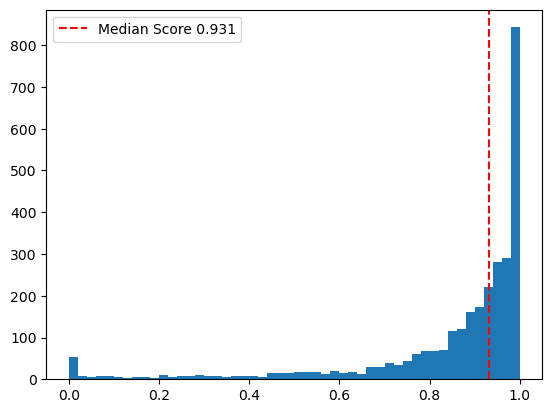

In [21]:
ov_consis_scores = load_h5(ov_perturbed_path, "AdaRandError_consis")
median_score = 1 - np.nanmedian(ov_consis_scores[:, 0])
plt.hist(1 - ov_consis_scores[:, 0], bins=50)
plt.axvline(x=median_score, color='r', linestyle='--', label=f'Median Score {median_score:.3f}')
plt.legend()
plt.show()

In [29]:
ids_low_consis = np.where(((1 - ov_consis_scores[:, 0]) > 0.6) & (1 - ov_consis_scores[:, 0] < 0.8))[0]
print(len(ids_low_consis))

355


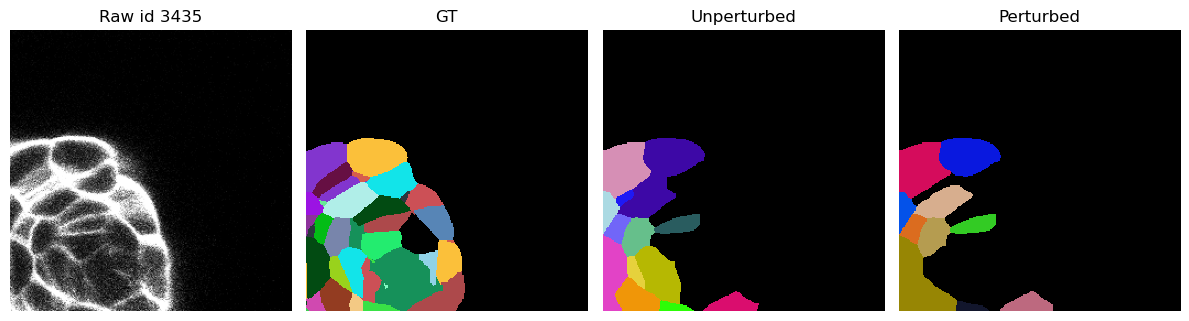

In [35]:
id = ids_low_consis[180]
_, axs = plt.subplots(1, 4, figsize=(12, 4))
patch_roi = get_roi_slice(ov_patch_indexes[id])
axs[0].imshow(ov_raw[patch_roi].squeeze(), cmap="gray")
axs[0].set_title("Raw id {}".format(id))
axs[1].imshow(ov_gt[patch_roi].squeeze(), cmap=get_random_colors(ov_gt[patch_roi]), interpolation='nearest')
axs[1].set_title("GT")
axs[2].imshow(ov_seg_up[id].squeeze(), cmap=get_random_colors(ov_seg_up[id]), interpolation='nearest')
axs[2].set_title("Unperturbed")
axs[3].imshow(ov_seg_p[id].squeeze(), cmap=get_random_colors(ov_seg_p[id]), interpolation='nearest')
axs[3].set_title("Perturbed")
for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [37]:
print("Starting per-object consistency calculation...")

# Calculate per-object consistency scores
unperturbed_scores, perturbed_scores = per_object_adaRandError_eval(
    ov_seg_up[id], ov_seg_p[id], num_dilations=1, num_erosions=1
)

print("Per-object scores using unperturbed instances as reference:")
print("Instance ID -> (Adapted Rand Error, Precision, Recall)")
for inst_id, (are, prec, rec) in list(unperturbed_scores.items())[:10]:  # Show first 10
    print(f"  {inst_id}: ARE={are:.4f}, Prec={prec:.4f}, Rec={rec:.4f}")

print("\nPer-object scores using perturbed instances as reference:")
print("Instance ID -> (Adapted Rand Error, Precision, Recall)")
for inst_id, (are, prec, rec) in list(perturbed_scores.items())[:10]:  # Show first 10
    print(f"  {inst_id}: ARE={are:.4f}, Prec={prec:.4f}, Rec={rec:.4f}")

print(f"\nNumber of instances in unperturbed: {len(unperturbed_scores)}")
print(f"Number of instances in perturbed: {len(perturbed_scores)}")

Starting per-object consistency calculation...
Per-object scores using unperturbed instances as reference:
Instance ID -> (Adapted Rand Error, Precision, Recall)
  (0, 1): ARE=0.4061, Prec=0.4223, Rec=1.0000
  (0, 2): ARE=0.0000, Prec=1.0000, Rec=1.0000
  (0, 3): ARE=1.0000, Prec=0.0000, Rec=nan
  (0, 4): ARE=0.0000, Prec=1.0000, Rec=1.0000
  (0, 5): ARE=0.0000, Prec=1.0000, Rec=1.0000
  (0, 6): ARE=0.0000, Prec=1.0000, Rec=1.0000
  (0, 7): ARE=0.0000, Prec=1.0000, Rec=1.0000
  (0, 8): ARE=0.0000, Prec=1.0000, Rec=1.0000
  (0, 9): ARE=1.0000, Prec=0.0000, Rec=nan
  (0, 10): ARE=1.0000, Prec=0.0000, Rec=nan

Per-object scores using perturbed instances as reference:
Instance ID -> (Adapted Rand Error, Precision, Recall)
  (0, 1): ARE=0.0000, Prec=1.0000, Rec=1.0000
  (0, 2): ARE=0.0059, Prec=0.9883, Rec=1.0000
  (0, 3): ARE=0.0000, Prec=1.0000, Rec=1.0000
  (0, 4): ARE=0.0000, Prec=1.0000, Rec=1.0000
  (0, 5): ARE=0.0000, Prec=1.0000, Rec=1.0000
  (0, 6): ARE=0.0000, Prec=1.0000, Rec=1.0

invalid value encountered in scalar divide


In [39]:
unperturbed_scores

{(0, 1): (0.4061241562435438, 0.42234950670571914, 1.0),
 (0, 2): (0.0, 1.0, 1.0),
 (0, 3): (1.0, 0.0, nan),
 (0, 4): (0.0, 1.0, 1.0),
 (0, 5): (0.0, 1.0, 1.0),
 (0, 6): (0.0, 1.0, 1.0),
 (0, 7): (0.0, 1.0, 1.0),
 (0, 8): (0.0, 1.0, 1.0),
 (0, 9): (1.0, 0.0, nan),
 (0, 10): (1.0, 0.0, nan),
 (0, 11): (0.0, 1.0, 1.0),
 (0, 12): (0.0020618556701030855, 0.9958847736625515, 1.0),
 (0, 13): (0.0, 1.0, 1.0)}

In [38]:
# Compare with overall consistency score
overall_consistency, _ = adaRandError_eval(ov_seg_up[id], ov_seg_p[id], incomplete_gt=False)
print(f"Overall consistency (ARE, Precision, Recall): {overall_consistency}")

# Analyze per-object scores
unp_ares = [score[0] for score in unperturbed_scores.values() if not np.isnan(score[0])]
pert_ares = [score[0] for score in perturbed_scores.values() if not np.isnan(score[0])]

print(f"\nPer-object ARE statistics (unperturbed instances as reference):")
print(f"  Mean: {np.mean(unp_ares):.4f}")
print(f"  Std:  {np.std(unp_ares):.4f}")
print(f"  Min:  {np.min(unp_ares):.4f}")
print(f"  Max:  {np.max(unp_ares):.4f}")

print(f"\nPer-object ARE statistics (perturbed instances as reference):")
print(f"  Mean: {np.mean(pert_ares):.4f}")
print(f"  Std:  {np.std(pert_ares):.4f}")
print(f"  Min:  {np.min(pert_ares):.4f}")
print(f"  Max:  {np.max(pert_ares):.4f}")

# Find instances with highest inconsistency
print(f"\nTop 5 most inconsistent instances (unperturbed as reference):")
sorted_unp = sorted(unperturbed_scores.items(), key=lambda x: x[1][0], reverse=True)
for i, (inst_id, (are, prec, rec)) in enumerate(sorted_unp[:5]):
    print(f"  {i+1}. Instance {inst_id}: ARE={are:.4f}, Prec={prec:.4f}, Rec={rec:.4f}")

print(f"\nTop 5 most inconsistent instances (perturbed as reference):")
sorted_pert = sorted(perturbed_scores.items(), key=lambda x: x[1][0], reverse=True)
for i, (inst_id, (are, prec, rec)) in enumerate(sorted_pert[:5]):
    print(f"  {i+1}. Instance {inst_id}: ARE={are:.4f}, Prec={prec:.4f}, Rec={rec:.4f}")

Overall consistency (ARE, Precision, Recall): [[0.31182563 0.81205124 0.59708947]]

Per-object ARE statistics (unperturbed instances as reference):
  Mean: 0.2622
  Std:  0.4180
  Min:  0.0000
  Max:  1.0000

Per-object ARE statistics (perturbed instances as reference):
  Mean: 0.0328
  Std:  0.0964
  Min:  0.0000
  Max:  0.3218

Top 5 most inconsistent instances (unperturbed as reference):
  1. Instance (0, 3): ARE=1.0000, Prec=0.0000, Rec=nan
  2. Instance (0, 9): ARE=1.0000, Prec=0.0000, Rec=nan
  3. Instance (0, 10): ARE=1.0000, Prec=0.0000, Rec=nan
  4. Instance (0, 1): ARE=0.4061, Prec=0.4223, Rec=1.0000
  5. Instance (0, 12): ARE=0.0021, Prec=0.9959, Rec=1.0000

Top 5 most inconsistent instances (perturbed as reference):
  1. Instance (0, 8): ARE=0.3218, Prec=0.5131, Rec=1.0000
  2. Instance (0, 2): ARE=0.0059, Prec=0.9883, Rec=1.0000
  3. Instance (0, 1): ARE=0.0000, Prec=1.0000, Rec=1.0000
  4. Instance (0, 3): ARE=0.0000, Prec=1.0000, Rec=1.0000
  5. Instance (0, 4): ARE=0.00

# FlyWing

In [5]:
fw_gt_path = "/scratch/talks/data/FlyWing/GT/test/per03.h5"
fw_gt = load_h5(fw_gt_path, "volumes/labels/expanded_cells_with_ignore")
fw_raw = load_h5(fw_gt_path, "volumes/raw")

In [6]:
path_perturbed = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P2/fw_model_Unet2/norm_50_950/gauss_a015-02/predictions/per03_predictions.h5"
path_unperturbed = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P2/fw_model_Unet2/norm_50_950/none/predictions/per03_predictions.h5"

seg_p = load_h5(path_perturbed, "segmentation")
seg_up = load_h5(path_unperturbed, "segmentation")
patch_indexes = load_h5(path_unperturbed, "patch_index")

In [6]:
print(seg_p.shape, seg_up.shape)

(1440, 1, 1, 256, 256) (1440, 1, 1, 256, 256)


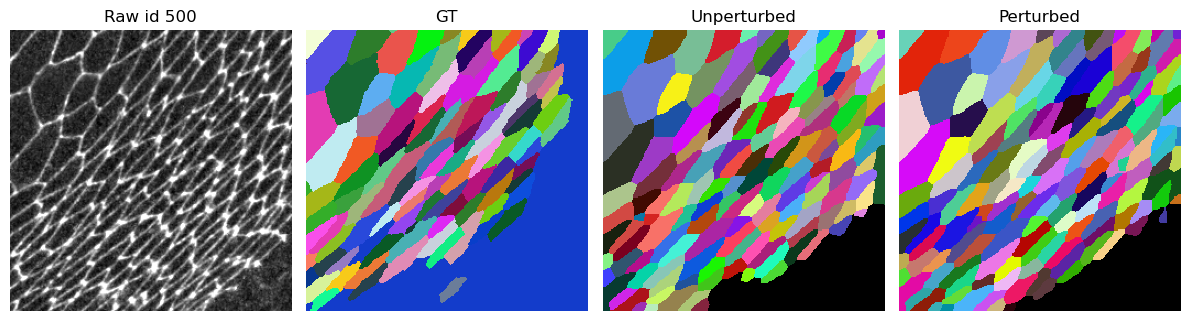

In [7]:
id = 500
_, axs = plt.subplots(1, 4, figsize=(12, 4))
patch_roi = get_roi_slice(patch_indexes[id])
axs[0].imshow(fw_raw[patch_roi].squeeze(), cmap="gray")
axs[0].set_title("Raw id {}".format(id))
axs[1].imshow(fw_gt[patch_roi].squeeze(), cmap=get_random_colors(fw_gt[patch_roi]), interpolation='nearest')
axs[1].set_title("GT")
axs[2].imshow(seg_up[id].squeeze(), cmap=get_random_colors(seg_up[id]), interpolation='nearest')
axs[2].set_title("Unperturbed")
axs[3].imshow(seg_p[id].squeeze(), cmap=get_random_colors(seg_p[id]), interpolation='nearest')
axs[3].set_title("Perturbed")
for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()


In [14]:
consistency, _ = adaRandError_eval(seg_up[id], seg_p[id], incomplete_gt=False)
print(consistency)

[[0.02114058 0.98356813 0.9741956 ]]


In [8]:
# Let's define the function directly in the notebook for testing
import numpy as np
from typing import Dict, Tuple, Optional, Union, Any
from numpy.typing import NDArray
from skimage.metrics import adapted_rand_error
from model_ranking import get_mask, get_border_mask, assign_unique_ids_to_value

def per_object_adaRandError_eval(
    pred_unperturbed: NDArray[Union[np.uint8, np.uint16, np.uint32, np.uint64]],
    pred_perturbed: NDArray[Union[np.uint8, np.uint16, np.uint32, np.uint64]],
    num_dilations: Optional[int] = 1,
    num_erosions: Optional[int] = 1,
) -> Tuple[Dict[int, Tuple[float, float, float]], Dict[int, Tuple[float, float, float]]]:
    """
    Calculate per-object foreground restricted Adapted Rand Error between 
    unperturbed and perturbed instance segmentation predictions.
    
    For each instance in both images, calculates the consistency by treating
    that instance as the "ground truth" and the corresponding region in the
    other image as the "prediction".
    
    Args:
        pred_unperturbed: Unperturbed instance segmentation prediction
        pred_perturbed: Perturbed instance segmentation prediction  
        num_dilations: Number of dilations for border mask (optional)
        num_erosions: Number of erosions for border mask (optional)
        
    Returns:
        Tuple of two dictionaries:
        - First dict: Per-object scores using unperturbed instances as reference
        - Second dict: Per-object scores using perturbed instances as reference
        Each dict maps instance_id -> (are, precision, recall)
    """
    assert pred_unperturbed.shape == pred_perturbed.shape, \
        f"Predictions have different shapes: {pred_unperturbed.shape} vs {pred_perturbed.shape}"
    
    # Handle 2D case
    unperturbed_scores = {}
    perturbed_scores = {}
    
    # Get unique instance IDs (excluding background=0)
    unp_instances = np.unique(pred_unperturbed)
    unp_instances = unp_instances[unp_instances != 0]
    
    pert_instances = np.unique(pred_perturbed)
    pert_instances = pert_instances[pert_instances != 0]
    
    # Calculate scores using unperturbed instances as reference
    for instance_id in unp_instances:
        are, prec, rec = _calculate_per_object_consistency(
            pred_unperturbed, pred_perturbed, instance_id, num_dilations, num_erosions
        )
        unperturbed_scores[instance_id] = (are, prec, rec)
        
    # Calculate scores using perturbed instances as reference  
    for instance_id in pert_instances:
        are, prec, rec = _calculate_per_object_consistency(
            pred_perturbed, pred_unperturbed, instance_id, num_dilations, num_erosions
        )
        perturbed_scores[instance_id] = (are, prec, rec)
    
    return unperturbed_scores, perturbed_scores


def _calculate_per_object_consistency(
    reference_img: NDArray[Any],
    comparison_img: NDArray[Any], 
    instance_id: int,
    num_dilations: Optional[int] = 1,
    num_erosions: Optional[int] = 1,
) -> Tuple[float, float, float]:
    """
    Helper function to calculate consistency for a single object instance.
    
    Args:
        reference_img: Image containing the reference instance 
        comparison_img: Image to compare against
        instance_id: ID of the instance to analyze
        num_dilations: Number of dilations for border mask
        num_erosions: Number of erosions for border mask
        
    Returns:
        Tuple of (adapted_rand_error, precision, recall)
    """
    # Create mask for the specific instance
    instance_mask = reference_img == instance_id
    
    if not np.any(instance_mask):
        return float("nan"), float("nan"), float("nan")
    
    # Create foreground mask (union of instance regions in both images)
    foreground_mask = get_mask(reference_img, comparison_img, threshold=0)
    
    # Combine instance mask with foreground mask
    eval_mask = np.logical_and(instance_mask, foreground_mask)
    
    # Apply border mask if specified
    if num_dilations is not None and num_erosions is not None:
        border_mask = get_border_mask(
            img=reference_img, 
            num_dilations=num_dilations, 
            num_erosions=num_erosions
        )
        eval_mask = np.logical_and(eval_mask, ~border_mask)
    
    if not np.any(eval_mask):
        return float("nan"), float("nan"), float("nan")
    
    # Extract regions within evaluation mask
    ref_region = reference_img[eval_mask]
    comp_region = comparison_img[eval_mask] 
    
    # For foreground restricted evaluation, assign unique IDs to background pixels
    # in the comparison region that fall within our evaluation mask
    ref_region_processed = assign_unique_ids_to_value(ref_region, value=[0])
    comp_region_processed = assign_unique_ids_to_value(comp_region, value=[0])
    
    try:
        are, prec, rec = adapted_rand_error(
            ref_region_processed,
            comp_region_processed, 
            ignore_labels=None,
        )
        
        # Ensure return types are floats
        return float(are), float(prec), float(rec)
        
    except Exception as e:
        print(f"Error calculating adapted rand error for instance {instance_id}: {e}")
        return float("nan"), float("nan"), float("nan")

print("Starting per-object consistency calculation...")

# Calculate per-object consistency scores
unperturbed_scores, perturbed_scores = per_object_adaRandError_eval(
    seg_up[id], seg_p[id], num_dilations=1, num_erosions=1
)

print("Per-object scores using unperturbed instances as reference:")
print("Instance ID -> (Adapted Rand Error, Precision, Recall)")
for inst_id, (are, prec, rec) in list(unperturbed_scores.items())[:10]:  # Show first 10
    print(f"  {inst_id}: ARE={are:.4f}, Prec={prec:.4f}, Rec={rec:.4f}")

print("\nPer-object scores using perturbed instances as reference:")
print("Instance ID -> (Adapted Rand Error, Precision, Recall)")
for inst_id, (are, prec, rec) in list(perturbed_scores.items())[:10]:  # Show first 10
    print(f"  {inst_id}: ARE={are:.4f}, Prec={prec:.4f}, Rec={rec:.4f}")

print(f"\nNumber of instances in unperturbed: {len(unperturbed_scores)}")
print(f"Number of instances in perturbed: {len(perturbed_scores)}")

Starting per-object consistency calculation...


invalid value encountered in scalar divide


Per-object scores using unperturbed instances as reference:
Instance ID -> (Adapted Rand Error, Precision, Recall)
  1: ARE=0.0000, Prec=1.0000, Rec=1.0000
  2: ARE=0.0000, Prec=1.0000, Rec=1.0000
  3: ARE=0.0000, Prec=1.0000, Rec=1.0000
  4: ARE=0.0160, Prec=0.9685, Rec=1.0000
  5: ARE=0.0000, Prec=1.0000, Rec=1.0000
  6: ARE=0.0000, Prec=1.0000, Rec=1.0000
  7: ARE=0.0000, Prec=1.0000, Rec=1.0000
  8: ARE=0.0000, Prec=1.0000, Rec=1.0000
  9: ARE=0.0000, Prec=1.0000, Rec=1.0000
  10: ARE=0.0000, Prec=1.0000, Rec=1.0000

Per-object scores using perturbed instances as reference:
Instance ID -> (Adapted Rand Error, Precision, Recall)
  1: ARE=0.0000, Prec=1.0000, Rec=1.0000
  2: ARE=0.0000, Prec=1.0000, Rec=1.0000
  3: ARE=0.0177, Prec=0.9653, Rec=1.0000
  4: ARE=0.0000, Prec=1.0000, Rec=1.0000
  5: ARE=0.0000, Prec=1.0000, Rec=1.0000
  6: ARE=0.0000, Prec=1.0000, Rec=1.0000
  7: ARE=0.0000, Prec=1.0000, Rec=1.0000
  8: ARE=0.0000, Prec=1.0000, Rec=1.0000
  9: ARE=0.0000, Prec=1.0000, Re

In [9]:
# Compare with overall consistency score
overall_consistency, _ = adaRandError_eval(seg_up[id], seg_p[id], incomplete_gt=False)
print(f"Overall consistency (ARE, Precision, Recall): {overall_consistency}")

# Analyze per-object scores
unp_ares = [score[0] for score in unperturbed_scores.values() if not np.isnan(score[0])]
pert_ares = [score[0] for score in perturbed_scores.values() if not np.isnan(score[0])]

print(f"\nPer-object ARE statistics (unperturbed instances as reference):")
print(f"  Mean: {np.mean(unp_ares):.4f}")
print(f"  Std:  {np.std(unp_ares):.4f}")
print(f"  Min:  {np.min(unp_ares):.4f}")
print(f"  Max:  {np.max(unp_ares):.4f}")

print(f"\nPer-object ARE statistics (perturbed instances as reference):")
print(f"  Mean: {np.mean(pert_ares):.4f}")
print(f"  Std:  {np.std(pert_ares):.4f}")
print(f"  Min:  {np.min(pert_ares):.4f}")
print(f"  Max:  {np.max(pert_ares):.4f}")

# Find instances with highest inconsistency
print(f"\nTop 5 most inconsistent instances (unperturbed as reference):")
sorted_unp = sorted(unperturbed_scores.items(), key=lambda x: x[1][0], reverse=True)
for i, (inst_id, (are, prec, rec)) in enumerate(sorted_unp[:5]):
    print(f"  {i+1}. Instance {inst_id}: ARE={are:.4f}, Prec={prec:.4f}, Rec={rec:.4f}")

print(f"\nTop 5 most inconsistent instances (perturbed as reference):")
sorted_pert = sorted(perturbed_scores.items(), key=lambda x: x[1][0], reverse=True)
for i, (inst_id, (are, prec, rec)) in enumerate(sorted_pert[:5]):
    print(f"  {i+1}. Instance {inst_id}: ARE={are:.4f}, Prec={prec:.4f}, Rec={rec:.4f}")

Overall consistency (ARE, Precision, Recall): [[0.02114058 0.98356813 0.9741956 ]]

Per-object ARE statistics (unperturbed instances as reference):
  Mean: 0.0201
  Std:  0.1039
  Min:  0.0000
  Max:  1.0000

Per-object ARE statistics (perturbed instances as reference):
  Mean: 0.0374
  Std:  0.1709
  Min:  0.0000
  Max:  1.0000

Top 5 most inconsistent instances (unperturbed as reference):
  1. Instance 101: ARE=1.0000, Prec=0.0000, Rec=nan
  2. Instance 67: ARE=0.4320, Prec=0.3966, Rec=1.0000
  3. Instance 72: ARE=0.3215, Prec=0.5134, Rec=1.0000
  4. Instance 97: ARE=0.3206, Prec=0.5144, Rec=1.0000
  5. Instance 99: ARE=0.3157, Prec=0.5201, Rec=1.0000

Top 5 most inconsistent instances (perturbed as reference):
  1. Instance 104: ARE=1.0000, Prec=0.0000, Rec=nan
  2. Instance 138: ARE=1.0000, Prec=0.0000, Rec=nan
  3. Instance 140: ARE=1.0000, Prec=0.0000, Rec=nan
  4. Instance 148: ARE=1.0000, Prec=0.0000, Rec=nan
  5. Instance 136: ARE=0.5465, Prec=0.2933, Rec=1.0000


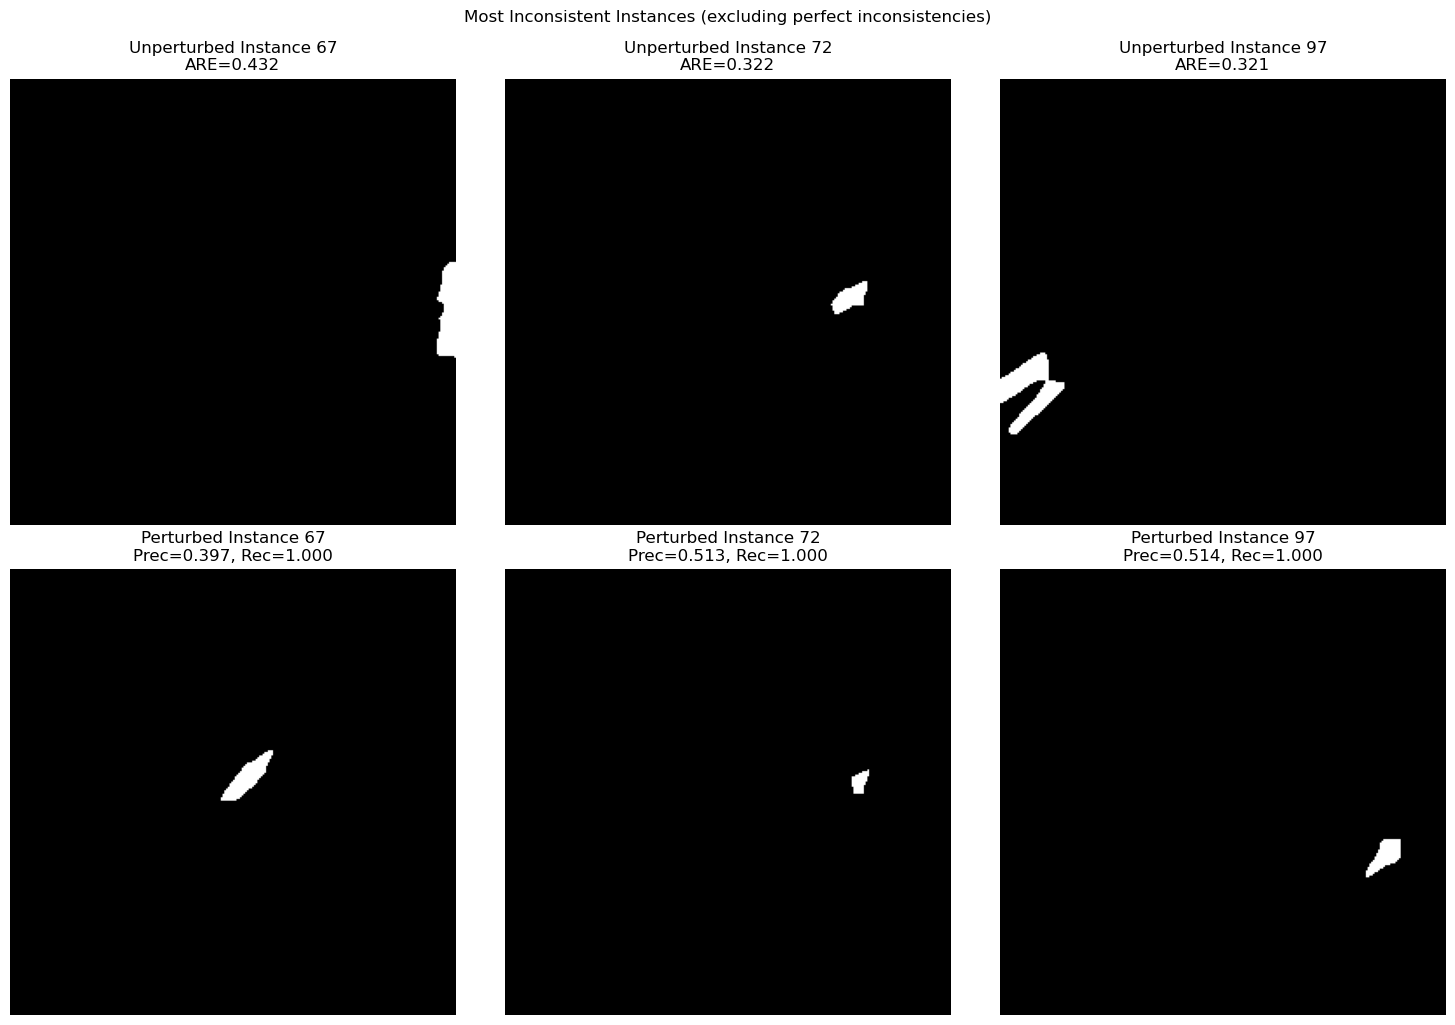


Instances that completely disappeared from unperturbed to perturbed: 1
Examples: [101]

Instances that completely appeared in perturbed (not in unperturbed): 4
Examples: [104, 138, 140, 148]


In [10]:
# Visualize some of the most inconsistent instances
import matplotlib.pyplot as plt

# Get the most inconsistent instances (excluding perfect inconsistency cases)
filtered_unp = [(inst_id, scores) for inst_id, scores in unperturbed_scores.items() 
                if 0 < scores[0] < 1.0 and not np.isnan(scores[0])]
filtered_unp = sorted(filtered_unp, key=lambda x: x[1][0], reverse=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, (inst_id, (are, prec, rec)) in enumerate(filtered_unp[:3]):
    # Create masks for this instance
    unp_mask = seg_up[id].squeeze() == inst_id
    pert_mask = seg_p[id].squeeze() == inst_id
    
    # Show unperturbed instance
    axes[0, i].imshow(unp_mask, cmap='gray')
    axes[0, i].set_title(f'Unperturbed Instance {inst_id}\nARE={are:.3f}')
    axes[0, i].axis('off')
    
    # Show perturbed instance
    axes[1, i].imshow(pert_mask, cmap='gray')
    axes[1, i].set_title(f'Perturbed Instance {inst_id}\nPrec={prec:.3f}, Rec={rec:.3f}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.suptitle('Most Inconsistent Instances (excluding perfect inconsistencies)', y=1.02)
plt.show()

# Show some statistics about instances that completely disappeared/appeared
disappeared = [inst_id for inst_id, scores in unperturbed_scores.items() 
               if scores[0] == 1.0 and np.isnan(scores[2])]
appeared = [inst_id for inst_id, scores in perturbed_scores.items() 
            if scores[0] == 1.0 and np.isnan(scores[2])]

print(f"\nInstances that completely disappeared from unperturbed to perturbed: {len(disappeared)}")
print(f"Examples: {disappeared[:5]}")
print(f"\nInstances that completely appeared in perturbed (not in unperturbed): {len(appeared)}")
print(f"Examples: {appeared[:5]}")

In [9]:
# Test the corrected per-object function
print("Testing corrected per-object Adapted Rand Error implementation...")

# Reload the module to get the updated function
import importlib
import model_ranking.metrics
importlib.reload(model_ranking.metrics)

# First let's debug the shape issue
print(f"seg_up[id] shape: {seg_up[id].shape}")
print(f"seg_p[id] shape: {seg_p[id].shape}")

# Check what np.where returns
test_mask = seg_up[id] > 0
coords = np.where(test_mask)
print(f"np.where returns {len(coords)} arrays")
print(f"Coordinate array shapes: {[c.shape for c in coords]}")

# Let's also check the squeezed version
test_mask_squeezed = seg_up[id].squeeze() > 0
coords_squeezed = np.where(test_mask_squeezed)
print(f"np.where on squeezed returns {len(coords_squeezed)} arrays")
print(f"Squeezed coordinate array shapes: {[c.shape for c in coords_squeezed]}")

# We should probably work with the squeezed 2D version
print("\nTesting with squeezed 2D images...")

# Re-import the updated function
from model_ranking.metrics import per_object_adaRandError_eval

# Test on squeezed 2D versions
seg_up_2d = seg_up[id].squeeze()
seg_p_2d = seg_p[id].squeeze()

test_id = 67  # One of the instances we saw had high inconsistency
id = 500  # The patch id we've been using

print(f"2D shapes: {seg_up_2d.shape}, {seg_p_2d.shape}")

# Get individual instance masks to manually verify
unp_mask_67 = seg_up_2d == test_id
pert_mask_67 = seg_p_2d == test_id

print(f"Instance {test_id}:")
print(f"  Pixels in unperturbed: {np.sum(unp_mask_67)}")
print(f"  Pixels in perturbed: {np.sum(pert_mask_67)}")
print(f"  Overlap pixels: {np.sum(unp_mask_67 & pert_mask_67)}")

# Calculate corrected per-object scores on 2D data
print("Calculating corrected per-object scores...")
unperturbed_scores_corrected, perturbed_scores_corrected = per_object_adaRandError_eval(
    seg_up_2d, seg_p_2d, num_dilations=1, num_erosions=1
)

print(f"\nCorrected scores for instance {test_id}:")
if test_id in unperturbed_scores_corrected:
    are, prec, rec = unperturbed_scores_corrected[test_id]
    print(f"  Unperturbed as reference: ARE={are:.4f}, Prec={prec:.4f}, Rec={rec:.4f}")
else:
    print(f"  Instance {test_id} not found in unperturbed scores")
    
if test_id in perturbed_scores_corrected:
    are, prec, rec = perturbed_scores_corrected[test_id]
    print(f"  Perturbed as reference: ARE={are:.4f}, Prec={prec:.4f}, Rec={rec:.4f}")
else:
    print(f"  Instance {test_id} not found in perturbed scores")

print(f"\nSummary statistics for corrected implementation:")
corrected_unp_ares = [score[0] for score in unperturbed_scores_corrected.values() if not np.isnan(score[0])]
corrected_pert_ares = [score[0] for score in perturbed_scores_corrected.values() if not np.isnan(score[0])]

print(f"Corrected unperturbed ARE: Mean={np.mean(corrected_unp_ares):.4f}, Std={np.std(corrected_unp_ares):.4f}")
print(f"Corrected perturbed ARE: Mean={np.mean(corrected_pert_ares):.4f}, Std={np.std(corrected_pert_ares):.4f}")
print(f"Number of instances: Unperturbed={len(unperturbed_scores_corrected)}, Perturbed={len(perturbed_scores_corrected)}")

Testing corrected per-object Adapted Rand Error implementation...
seg_up[id] shape: (1, 1, 256, 256)
seg_p[id] shape: (1, 1, 256, 256)
np.where returns 4 arrays
Coordinate array shapes: [(57269,), (57269,), (57269,), (57269,)]
np.where on squeezed returns 2 arrays
Squeezed coordinate array shapes: [(57269,), (57269,)]

Testing with squeezed 2D images...
2D shapes: (256, 256), (256, 256)
Instance 67:
  Pixels in unperturbed: 482
  Pixels in perturbed: 340
  Overlap pixels: 0
Calculating corrected per-object scores...

Corrected scores for instance 67:
  Unperturbed as reference: ARE=0.0059, Prec=0.9967, Rec=0.9974
  Perturbed as reference: ARE=0.0000, Prec=1.0000, Rec=1.0000

Summary statistics for corrected implementation:
Corrected unperturbed ARE: Mean=0.0003, Std=0.0010
Corrected perturbed ARE: Mean=0.0004, Std=0.0015
Number of instances: Unperturbed=143, Perturbed=149
